# Neural Networks Project: Assignment 2
## Image Recognition with Convolutional Neural Network (CNN)

This notebook contains the implementation of a Convolutional Neural Network (CNN) for image recognition. There are some explanations and testing metrics for the model, but for a full comparison for the whole assignment, see report.pdf. 

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import shutil
from pathlib import Path
import keras
from keras import layers, models
from keras.preprocessing import image_dataset_from_directory
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# def make_dirs():
#   for split in ["train", "validation", "test"]:
#       for c in class_names:
#         os.makedirs(new_base_dir / split / c, exist_ok=True)

# def split_and_copy(class_name, files):
#     files = np.array(files)

#     np.random.shuffle(files)

#     n = len(files)
#     train_end = int(0.7 * n)
#     val_end = int(0.85 * n)

#     train_files = files[:train_end]
#     val_files = files[train_end:val_end]
#     test_files = files[val_end:]

#     for f in train_files:
#         shutil.copy(original_dir/class_name/f, new_base_dir/"train"/class_name/f)

#     for f in val_files:
#         shutil.copy(original_dir/class_name/f, new_base_dir/"validation"/class_name/f)

#     for f in test_files:
#         shutil.copy(original_dir/class_name/f, new_base_dir/"test"/class_name/f)

In [2]:
# SEED = 42
# np.random.seed(SEED)
DATA_DIR = "./data/centered"
original_dir = Path(DATA_DIR)
new_base_dir = Path("./data_split")

class_names = sorted(os.listdir(original_dir))
# print(class_names)

# make_dirs()

# for c in class_names:
#     class_dir = original_dir / c
#     files = os.listdir(class_dir)

#     split_and_copy(c, files)

# print("Done splitting dataset.")

In [3]:

IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 210 files belonging to 5 classes.
Found 45 files belonging to 5 classes.
Found 45 files belonging to 5 classes.


In [4]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

## The CNN model
For the final baseline CNN model, the architecture consists of five layers of convolutional and max-pooling layers with batch normalization and dropout for regularization.The activation function used is ReLu and the amount of neurons in the layers are 32, 64, 128, 256 and 256 respectively. The model is trained for 50 epochs with early stopping with patience of 10 epochs. The learning rate is set to 1e-3 when the default for Adam optimizer is 1e-4. 

The model was tested with fewer layers, fewer neurons and without batch normalization and dropout, but the performance was worse. The use-bias=False means that the model does not learn a bias term, which helps in preventing overfitting. The evaluation of the model is done below.

In [5]:
def build_cnn():
    inputs = layers.Input(shape=(224, 224, 3))

    x = data_aug(inputs)


    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(5, activation="softmax")(x)

    return models.Model(inputs, outputs)

cnn_model = build_cnn()

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
    ]
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1571 - loss: 1.8664 - val_accuracy: 0.2000 - val_loss: 15.9403
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 914ms/step - accuracy: 0.2571 - loss: 1.6284 - val_accuracy: 0.2000 - val_loss: 5.2978
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 916ms/step - accuracy: 0.2571 - loss: 1.5436 - val_accuracy: 0.2000 - val_loss: 8.5233
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 976ms/step - accuracy: 0.3667 - loss: 1.4042 - val_accuracy: 0.2444 - val_loss: 5.3005
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 967ms/step - accuracy: 0.3810 - loss: 1.4691 - val_accuracy: 0.2222 - val_loss: 7.3757
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 925ms/step - accuracy: 0.3619 - loss: 1.3760 - val_accuracy: 0.2000 - val_loss: 3.1498
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 943ms/step - accuracy: 0.3857 - loss: 1.3531 - val_accuracy: 0.2000 - val_loss: 5.4981
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 949ms/step - accuracy: 0.4143 - loss: 1.2807 - val_accura

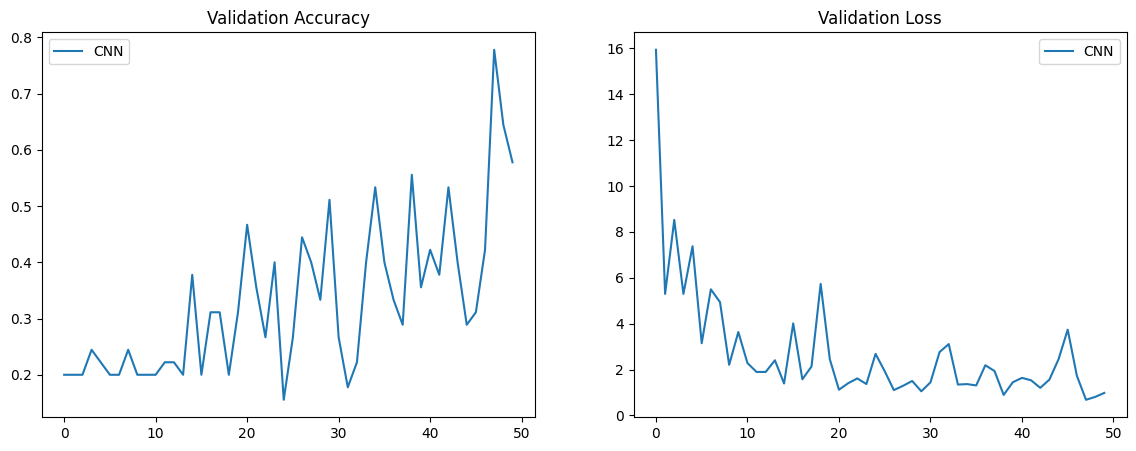

In [6]:

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_history.history["val_accuracy"], label="CNN")
plt.title("Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(cnn_history.history["val_loss"], label="CNN")
plt.title("Validation Loss")
plt.legend()

plt.show()

## Test Accuracy, Confusion Matrix and Mistaken Predictions

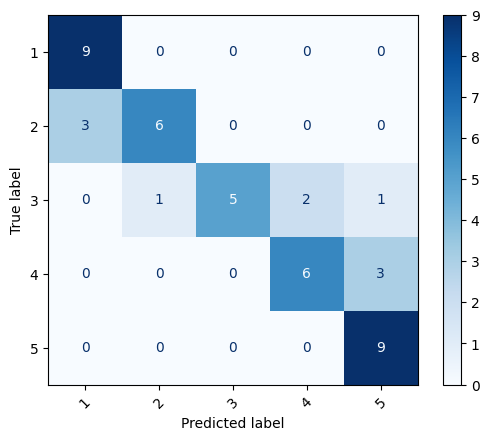

Manual Accuracy: 0.7777777777777778


In [7]:

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = cnn_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

acc = np.mean(np.array(y_true) == np.array(y_pred))
print("Manual Accuracy:", acc)

The test accuracy of the model is .78, which is fairly good considering the small size of the dataset. The model is able to learn the features of the images and classify them with good accuracy. As seen on the confusion matrix, the mistakes are mostly between classes that are similar to each other (for example, class 3 is mistaken for class 2 and class 4). Below are shown the mistaken predictions of the model and as seen, the model might not be able to fully understand the depth of the images, which result in the mistakes between classes that are similar. Better results could have been achieved with more data or more uniform data, so that all the images were taken from the same side of the hand and for each class same fingers would be lifted (ie. for class 1, always the index finger, for class 2 always the index and middle finger etc.).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


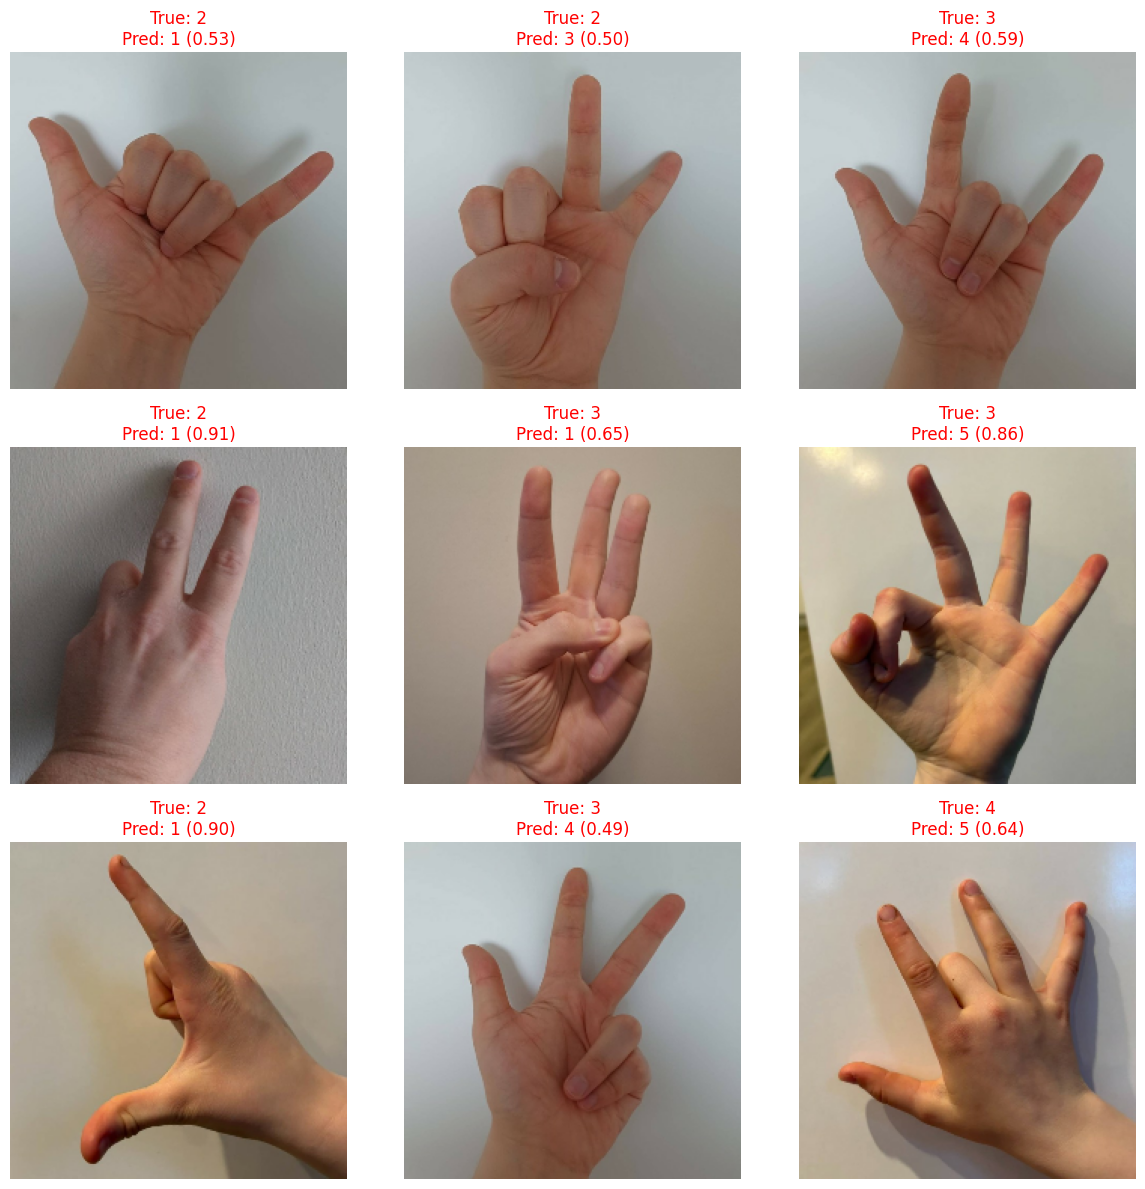

In [8]:
wrong_images = []
wrong_true = []
wrong_pred = []
wrong_probs = []

# collect wrong predictions
for images, labels in test_ds:
    preds = cnn_model.predict(images)

    for i in range(len(images)):
        pred_idx = np.argmax(preds[i])

        if pred_idx != labels[i]:
            wrong_images.append(images[i].numpy().astype("uint8"))
            wrong_true.append(class_names[labels[i]])
            wrong_pred.append(class_names[pred_idx])
            wrong_probs.append(preds[i])

# how many to show
N = min(9, len(wrong_images))

plt.figure(figsize=(12, 12))

for i in range(N):
    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(wrong_images[i])
    plt.axis("off")

    confidence = np.max(wrong_probs[i])

    plt.title(
        f"True: {wrong_true[i]}\nPred: {wrong_pred[i]} ({confidence:.2f})",
        color="red"
    )

plt.tight_layout()
plt.show()